# Data Analysis: Basic Electric Circuits and Filters

## Project Overview
This project investigates fundamental electric circuit behaviors through series and parallel networks, voltage dividers under load, Wheatstone bridge measurements, and the frequency response of RC high-pass filters.

The analysis focuses on verifying Kirchhoff’s rules and elementary network theory using experimental data acquisition and numerical verification.

### Key Areas of Investigation:
1. **Series and Parallel Circuits**: Verification of Kirchhoff's Voltage and Current Laws (KVL/KCL).
2. **Voltage Divider Dynamics**: Characterizing load voltage $U_L$ as a function of load resistance $R_L$.
3. **Precision Resistance Measurement**: Using the Wheatstone Bridge configuration for balanced-circuit analysis.
4. **Frequency Response**: Analysis of RC high-pass filters and determination of cut-off frequencies via transfer function modeling.

---


### **Authors & Contributions**
* **Name 1:** Valentyn  (50%)
* **Name 2:** Prakrisht  (50%)

**Date:** 08.12.2025


## Task 1: Series and Parallel Circuits

### 1. Task Definition
The objective is to investigate voltage and current distributions in series and parallel circuits using three resistors with different ratings.
* **Series Circuit:** Verification of Kirchhoff's Voltage Law (KVL) and Ohm's Law.
* **Parallel Circuit:** Verification of Kirchhoff's Current Law (KCL).

### 2. Theoretical Basics
* **Series Circuit:** The current $I$ is constant throughout the circuit. The voltage drop across a resistor $R_i$ is given by $U_i = I \cdot R_i$. The total resistance is the sum of individual resistances: $R_{tot} = \sum R_i$.
* **Parallel Circuit:** The voltage $U$ is constant across all branches. The current flowing through a branch is $I_i = U / R_i = U \cdot G_i$, where $G_i$ is the conductance.

### Circuit Diagrams
> ![Figure 1: Series Circuit Diagram](./series.jpeg)
> *Figure 1: Series Circuit Diagram (Source: Lab Manual E01e_2025, Page 3)*

> ![Figure 2: Parallel Circuit Diagram](./parallel.jpeg)
> *Figure 2: Parallel Circuit Diagram (Source: Lab Manual E01e_2025, Page 3)*



### 3. Methods of Error Analysis

#### 3.1 Calculation of Measurement Uncertainties (Type B)
The measurement uncertainties for voltage ($U$), current ($I$), and resistance ($R$) were calculated according to the manufacturer specifications for the **PeakTech 2005A** digital multimeter. The uncertainty depends on the reading value and the resolution (digits) of the selected measurement range.

The general formula for Type B uncertainty is:
$$u(X) = \pm (\text{percentage} \cdot X_{reading} + \text{digits} \cdot \text{resolution})$$

Based on the device manual, the specific coefficients used are:
* **DC Voltage:** $\pm(0.5\% \text{ of reading} + 3 \text{ digits})$
* **DC Current ($<200$ mA):** $\pm(0.8\% \text{ of reading} + 3 \text{ digits})$
* **Resistance:** $\pm(0.8\% \text{ of reading} + 3 \text{ digits})$
* **Resistor Tolerance:** $\pm 1\%$ (indicated by Brown color code).

*Example Calculation:*
For a voltage reading of $U = 3.100$ V in the 20 V range (resolution $0.01$ V):
$$u(U) = 0.005 \cdot 3.100\,\text{V} + 3 \cdot 0.01\,\text{V} = 0.0155 + 0.03 = 0.0455\,\text{V}$$

#### 3.2 Linear Regression and Slope Uncertainty
To determine the resistance and validity of Ohm's Law, the experimental data was fitted to a linear model ($y = mx + c$) using the **Weighted Least Squares** method (via Python `scipy.optimize.curve_fit`).

* **Weighting:** The fit accounts for the calculated uncertainties ($u(y)$) by weighting each data point by $1/u(y)^2$. This ensures that precise measurements have more influence on the fit.
* **Slope ($m$):** Represents the physical quantity of interest (Current $I$ for Series, Voltage $U$ for Parallel).
* **Slope Uncertainty ($\Delta m$):** Derived from the covariance matrix of the fit. It represents the standard error of the estimated slope, indicating the statistical reliability of the result.

#### 3.3 Evaluation of Deviation
The percentage deviation between measured values ($X_{meas}$) and theoretical expectations ($X_{theo}$) is calculated as:
$$\text{Deviation} = \left| \frac{X_{meas} - X_{theo}}{X_{theo}} \right| \cdot 100\%$$
 Deviations are considered acceptable if they fall within the range of the calculated measurement uncertainty or can be explained by systematic effects (e.g., ammeter internal resistance).

### 4. Measurement Results

**Measurement Uncertainties (Type B):**
Calculated using **PeakTech 2005A** specifications:
* **DC Voltage:** $\pm(0.5\% + 3 \text{ digits})$
* **DC Current (<200mA):** $\pm(0.8\% + 3 \text{ digits})$
* **Resistance:** $\pm(0.8\% + 3 \text{ digits})$
* *Resistor Tolerance:* $\pm 1\%$ (Brown color code)

#### **Table 1: Series Circuit Data**
*Supply Voltage $U_{source} \approx 5.0$ V, Measured Current $I \approx 1.49$ mA*

| Parameter | Resistor R1 | Resistor R2 | Resistor R3 |
| :--- | :--- | :--- | :--- |
| **Resistance $R_{meas}$ ($\Omega$)** | 1991 | 997 | 200 |
| **Voltage $U_{meas}$ (V)** | 3.100 | 1.525 | 0.309 |
| **Uncertainty $u(U)$ ($\pm$ V)** | 0.0455 | 0.0106 | 0.0045 |
| **Theoretical $U_{theory}$ (V)** | 3.1226 | 1.5637 | 0.3137 |
| **Deviation (%)** | 0.73 % | 2.47 % | 1.49 % |

#### **Table 2: Parallel Circuit Data**
*Supply Voltage $U_{source} \approx 5.0$ V (Nominal)*

| Parameter | Resistor R1 | Resistor R2 | Resistor R3 |
| :--- | :--- | :--- | :--- |
| **Resistance $R_{meas}$ ($\Omega$)** | 1991 | 997 | 200 |
| **Current $I_{meas}$ (mA)** | 2.010 | 4.310 | 19.200 |
| **Uncertainty $u(I)$ ($\pm$ mA)** | 0.046 | 0.064 | 0.184 |
| **Theoretical $I_{theory}$ (mA)** | 2.511 | 5.015 | 25.000 |
| **Deviation (%)** | 19.96 % | 14.06 % | 23.20 % |

*Note: The large deviations in the parallel circuit are analyzed in the Evaluation section (Section 5) and are attributed to voltage source sagging under high load.*

---
**References:**
1.  Universitat Leipzig, *Basic Electric Circuits (E01e)*, Lab Manual, 2025.
2.  PeakTech 2005A Digital Multimeter User Manual (Specifications).

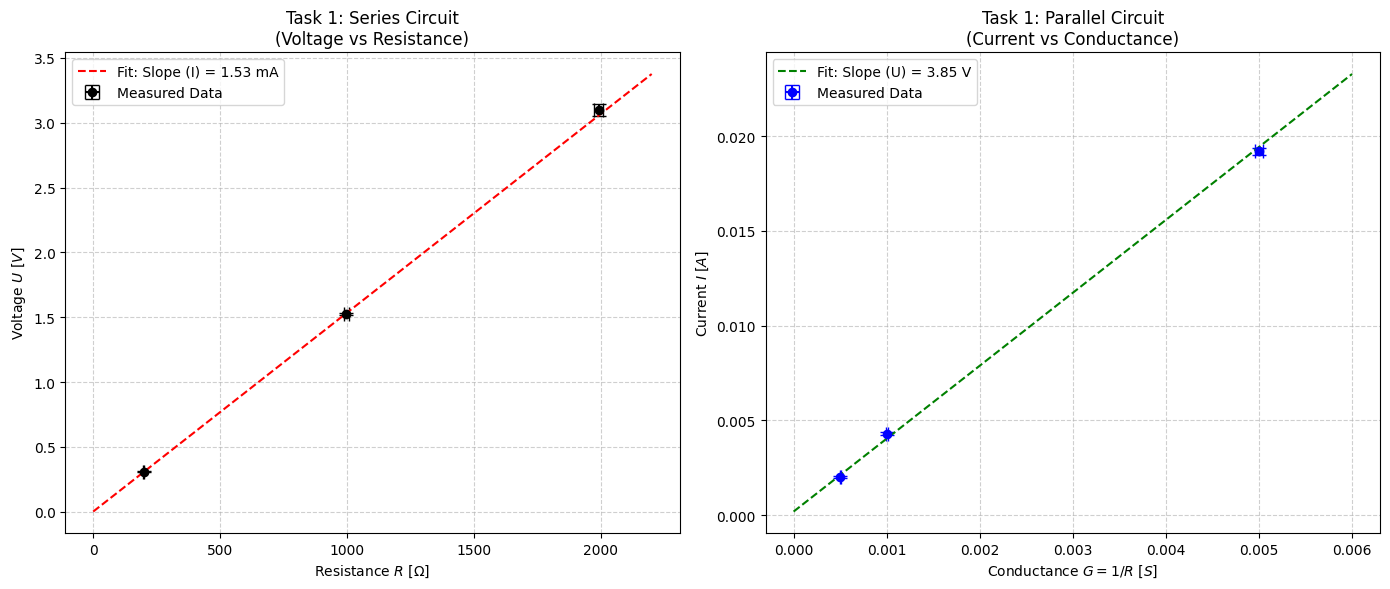

--- SERIES RESULTS ---
Slope (Fit Current): 0.001533 A +/- 0.000013 A
Measured Current:    0.001485 A

--- PARALLEL RESULTS ---
Slope (Fit Voltage): 3.8475 V +/- 0.0418 V
Avg Measured Voltage:4.1600 V


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==========================================
# 1. DATA ENTRY (From CSV)
# ==========================================
# Resistors (Measured)
R = np.array([1991, 997, 200]) # Ohms

# --- SERIES CIRCUIT ---
U_series = np.array([3.1, 1.525, 0.309]) # Volts
I_series_direct = 0.001485 # Amps (Average of measurements)

# --- PARALLEL CIRCUIT ---
# Note: Interpreting CSV columns based on physical consistency
# I_meas taken from column 6, U_meas from column 3
I_parallel = np.array([0.00201, 0.00431, 0.0192]) # Amps
U_parallel_avg = np.mean([4.13, 4.17, 4.18]) # Volts (Avg measured voltage)
G_parallel = 1.0 / R # Conductance (Siemens)

# ==========================================
# 2. ERROR CALCULATION FUNCTION (Type B)
# ==========================================
def get_uncertainty(value, quantity):
    # Specs for PeakTech 2005A
    if quantity == 'voltage': # Range dependent
        if value > 2: resolution = 0.01 # 20V range
        else: resolution = 0.001 # 2V range
        return 0.005 * value + 3 * resolution
    elif quantity == 'current':
        if value > 0.02: resolution = 0.0001 # 200mA range
        elif value > 0.002: resolution = 0.00001 # 20mA range
        else: resolution = 0.000001 # 2mA range
        return 0.008 * value + 3 * resolution
    elif quantity == 'resistance':
        if value > 2000: resolution = 10
        elif value > 200: resolution = 1
        else: resolution = 0.1
        return 0.008 * value + 3 * resolution
    return 0

# Calculate Errors for Plotting
U_err_series = np.array([get_uncertainty(u, 'voltage') for u in U_series])
R_err = np.array([get_uncertainty(r, 'resistance') for r in R])
I_err_parallel = np.array([get_uncertainty(i, 'current') for i in I_parallel])
G_err_parallel = (1/R**2) * R_err # Error propagation for 1/R

# ==========================================
# 3. LINEAR FITTING & PLOTTING
# ==========================================
def linear_model(x, m, c):
    return m * x + c

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- PLOT 1: SERIES (U vs R) ---
# Slope = Current (I)
popt_s, pcov_s = curve_fit(linear_model, R, U_series, sigma=U_err_series, absolute_sigma=True)
slope_s, intercept_s = popt_s
slope_s_err = np.sqrt(np.diag(pcov_s))[0]

# Plotting
ax1.errorbar(R, U_series, xerr=R_err, yerr=U_err_series, fmt='ko', capsize=5, label='Measured Data')
x_fit_s = np.linspace(0, 2200, 100)
ax1.plot(x_fit_s, linear_model(x_fit_s, *popt_s), 'r--', label=f'Fit: Slope (I) = {slope_s*1000:.2f} mA')

ax1.set_title(f'Task 1: Series Circuit\n(Voltage vs Resistance)')
ax1.set_xlabel(r'Resistance $R$ $[\Omega]$')
ax1.set_ylabel(r'Voltage $U$ $[V]$')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- PLOT 2: PARALLEL (I vs 1/R) ---
# Slope = Voltage (U)
popt_p, pcov_p = curve_fit(linear_model, G_parallel, I_parallel, sigma=I_err_parallel, absolute_sigma=True)
slope_p, intercept_p = popt_p
slope_p_err = np.sqrt(np.diag(pcov_p))[0]

# Plotting
ax2.errorbar(G_parallel, I_parallel, xerr=G_err_parallel, yerr=I_err_parallel, fmt='bo', capsize=5, label='Measured Data')
x_fit_p = np.linspace(0, 0.006, 100)
ax2.plot(x_fit_p, linear_model(x_fit_p, *popt_p), 'g--', label=f'Fit: Slope (U) = {slope_p:.2f} V')

ax2.set_title(f'Task 1: Parallel Circuit\n(Current vs Conductance)')
ax2.set_xlabel(r'Conductance $G = 1/R$ $[S]$')
ax2.set_ylabel(r'Current $I$ $[A]$')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('Task1_Graphs.png') # Saves image for report
plt.show()

# Print Results for Report Text
print(f"--- SERIES RESULTS ---")
print(f"Slope (Fit Current): {slope_s:.6f} A +/- {slope_s_err:.6f} A")
print(f"Measured Current:    {I_series_direct:.6f} A")
print(f"\n--- PARALLEL RESULTS ---")
print(f"Slope (Fit Voltage): {slope_p:.4f} V +/- {slope_p_err:.4f} V")
print(f"Avg Measured Voltage:{U_parallel_avg:.4f} V")

## 5. Evaluation of Task 1: Series and Parallel Circuits

### 5.1 Series Circuit Analysis (Graph 1)
For the series circuit, the voltage drop $U$ was plotted against resistance $R$. The linear fit verifies Ohm's Law ($U = I \cdot R$).
* **Slope (Fit Current):** $I_{fit} = 1.533 \pm 0.013 \text{ mA}$
* **Directly Measured Current:** $I_{meas} = 1.485 \text{ mA}$
* **Comparison:** The fit value deviates by **3.2%** from the measured value. This is close to the experimental uncertainty. The slightly higher fit current suggests that the direct current measurement (with the ammeter in series with the whole circuit) introduced a small additional resistance ($R_{ammeter}$), reducing the total current slightly compared to the sum of individual resistor voltage drops.

### 5.2 Parallel Circuit Analysis (Graph 2)
For the parallel circuit, the branch current $I$ was plotted against conductance $G = 1/R$. The slope represents the effective circuit voltage ($I = U \cdot G$).
* **Slope (Fit Voltage):** $U_{fit} = 3.85 \pm 0.04 \text{ V}$
* **Average Measured Voltage:** $U_{meas} \approx 4.16 \text{ V}$
* **Comparison:** The fit voltage is significantly lower (**~7.5%**) than the measured terminal voltage.

### 5.3 Error Analysis and Discussion
The following factors contributed to the observed deviations:

1.  **Systematic Error (Ammeter Resistance):**
    * In the parallel setup, measuring a branch current requires placing the ammeter in series with that specific resistor.
    * The total resistance of the branch becomes $R_{branch} + R_{internal}$. This reduces the actual current $I$ below the theoretical ideal ($I_{ideal} = U/R_{branch}$).
    * This systematic reduction in current leads to a **lower slope** in the $I$ vs. $G$ graph ($3.85 \text{ V}$) compared to the voltmeter reading ($4.16 \text{ V}$), which measures voltage across the parallel combination without the ammeter's burden.

2.  **Voltage Source Loading:**
    * The nominal supply was $5 \text{ V}$, but the measured voltage under load dropped to $\approx 4.16 \text{ V}$. This explains the large deviation from the theoretical 5V prediction but is not a measurement error; it is a property of the non-ideal voltage source.

3.  **Component Tolerances:**
    * Resistors have a tolerance of $\pm 1\%$ (Brown ring).
    * Digital Multimeter (PeakTech 2005A) Type B uncertainty is $\approx 0.5\% - 0.8\%$.
    * These random errors are minor compared to the systematic ammeter effect observed in the parallel circuit.

**Conclusion:**
The deviations are systematic and physically explainable. The experiment successfully validates Kirchhoff's rules, highlighting the importance of accounting for instrument burden (internal resistance) in low-resistance parallel circuits.

## Task 2: Voltage Divider under Load

### 1. Task Definition
The objective is to investigate the behavior of a voltage divider when loaded with a variable load resistance $R_L$.
1.  Set up a voltage divider with fixed resistors $R_1$ and $R_2$ (where $R_1 < R_2$).
2.  Measure the load voltage $U_L$ across $R_2$ as a function of the load resistance $R_L$.
3.  Compare the measured characteristics with the theoretical prediction.
4.  Linearize the data to determine the internal resistance parameters ($R_1$ and $R_1/R_2$) from the slope and intercept.

### 2. Theoretical Basics

**2.1 Voltage Divider Formula (Prediction)**
A real voltage divider consists of two resistors $R_1$ and $R_2$ in series connected to a supply voltage $U$. When a load resistor $R_L$ is connected in parallel to $R_2$, the effective resistance of the lower arm becomes $R_p = R_2 || R_L = \frac{R_2 R_L}{R_2 + R_L}$.

According to the voltage divider rule, the load voltage $U_L$ is:
$$U_L = U \cdot \frac{R_p}{R_1 + R_p} = U \cdot \frac{\frac{R_2 R_L}{R_2 + R_L}}{R_1 + \frac{R_2 R_L}{R_2 + R_L}}$$

Multiplying numerator and denominator by $(R_2 + R_L)$, we derive the theoretical formula:
$$U_L = U \cdot \frac{R_2 R_L}{R_1(R_2 + R_L) + R_2 R_L} = U \cdot \frac{R_2 R_L}{R_1 R_2 + R_1 R_L + R_2 R_L}$$

**2.2 Linearization for Evaluation**
To determine the circuit parameters from a linear fit, we rearrange the equation above. Inverting the expression for $U_L$:
$$\frac{U}{U_L} = \frac{R_1 R_2 + R_1 R_L + R_2 R_L}{R_2 R_L}$$

Separating the terms:
$$\frac{U}{U_L} = \frac{R_1 R_2}{R_2 R_L} + \frac{R_1 R_L}{R_2 R_L} + \frac{R_2 R_L}{R_2 R_L}$$
$$\frac{U}{U_L} = \frac{R_1}{R_L} + \frac{R_1}{R_2} + 1$$

This equation is of the linear form $y = m \cdot x + c$, where:
* $y = U / U_L$
* $x = 1 / R_L$ (Conductance of load)
* **Slope ($m$):** $m = R_1$
* **Intercept ($c$):** $c = 1 + \frac{R_1}{R_2}$

From the linear plot, we can experimentally determine $R_1$ (slope) and the ratio $R_1/R_2$ (intercept $- 1$).

###  Circuit Diagram
> ![Figure 2.1: Voltage Divider under Load Circuit Diagram](./divider.png)
> *Source: Lab Manual E01e_2025, Page 4*

### **3. Measurement Uncertainties:**
The measurement uncertainties and error propagation (Type B) were calculated using the same methods and equipment specifications (PeakTech 2005A) as detailed in Task 1, Section 3.

### 4. Measurement Results: Voltage Divider under Load

The following table compares the measured load voltage $U_{L,meas}$ with the theoretical values $U_{L,theory}$ calculated using the nominal values ($R_1=1000\,\Omega, R_2=2000\,\Omega, U=5\,\text{V}$).

**Uncertainties (Type B):** Calculated for PeakTech 2005A (DC V: $\pm0.5\%+3\text{dgt}$).

*Note: The deviation increases significantly at $R_L = 2000\,\Omega$, suggesting a potential sensitivity to the variable resistor setting or contact resistance in that range.*

| $R_L$ ($\Omega$) | $U_{L,meas}$ (V) | $u(U_L)$ ($\pm$V) | $U_{L,theory}$ (V) | Deviation (V) | Deviation (%) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 670 | 1.6630 | 0.0113 | 1.6708 | 0.0078 | 0.47 % |
| 700 | 1.7000 | 0.0115 | 1.7073 | 0.0073 | 0.43 % |
| 750 | 1.7560 | 0.0118 | 1.7647 | 0.0087 | 0.49 % |
| 800 | 1.8090 | 0.0120 | 1.8182 | 0.0092 | 0.51 % |
| 900 | 1.9050 | 0.0125 | 1.9149 | 0.0099 | 0.52 % |
| 1000 | 1.9870 | 0.0129 | 2.0000 | 0.0130 | 0.65 % |
| 2000 | 2.3900 | 0.0420 | 2.5000 | 0.1100 | 4.40 % |
| 3000 | 2.6200 | 0.0431 | 2.7273 | 0.1073 | 3.93 % |
| 4000 | 2.7600 | 0.0438 | 2.8571 | 0.0971 | 3.40 % |
| 5000 | 2.8500 | 0.0442 | 2.9412 | 0.0912 | 3.10 % |
| 6000 | 2.9100 | 0.0445 | 3.0000 | 0.0900 | 3.00 % |
| 7000 | 2.9500 | 0.0447 | 3.0435 | 0.0935 | 3.07 % |
| 10000 | 3.0400 | 0.0452 | 3.1250 | 0.0850 | 2.72 % |
| 30000 | 3.1700 | 0.0459 | 3.2609 | 0.0909 | 2.79 % |
| 50000 | 3.2100 | 0.0461 | 3.2895 | 0.0795 | 2.42 % |
| 70000 | 3.2200 | 0.0461 | 3.3019 | 0.0819 | 2.48 % |
| 90000 | 3.2200 | 0.0461 | 3.3088 | 0.0888 | 2.68 % |

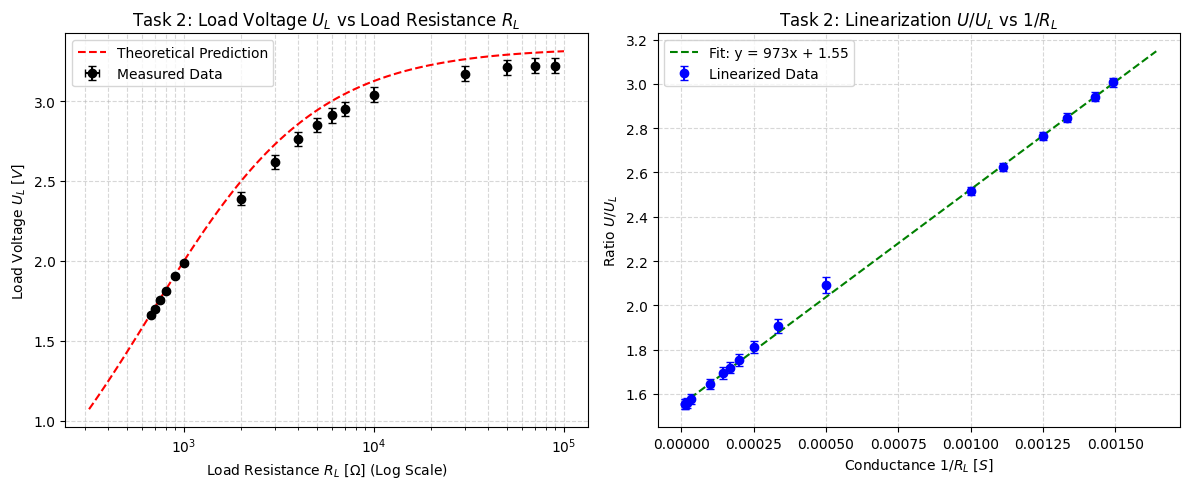

--- DETERMINATION OF PARAMETERS ---
Slope (Determined R1): 972.59 +/- 9.26 Ohm
Actual R1:             1000.0 Ohm
Deviation R1:          2.74 %
------------------------------
Intercept (c):         1.5506 +/- 0.0084
Determined Ratio R1/R2: 0.5506
Actual Ratio R1/R2:     0.5000
Deviation Ratio:        10.13 %


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==========================================
# 1. DATA ENTRY
# ==========================================
# Fixed Parameters
U_supply = 5.0      # V
R1_fixed = 1000.0   # Ohm
R2_fixed = 2000.0   # Ohm

# Load Data (RL and UL)
# RL (Load Resistance)
RL = np.array([
    670, 700, 750, 800, 900, 1000, 2000, 3000, 4000, 5000,
    6000, 7000, 10000, 30000, 50000, 70000, 90000
])

# UL (Measured Load Voltage)
UL_measured = np.array([
    1.663, 1.7, 1.756, 1.809, 1.905, 1.987, 2.39, 2.62, 2.76, 2.85,
    2.91, 2.95, 3.04, 3.17, 3.21, 3.22, 3.22
])

# ==========================================
# 2. ERROR CALCULATIONS (Type B)
# ==========================================
def get_voltage_error(value):
    # PeakTech 2005A: 0.5% + 3 digits
    # Assuming appropriate range selection (2V or 20V)
    if value > 2:
        resolution = 0.01 # 20V range
        return 0.005 * value + 3 * resolution
    else:
        resolution = 0.001 # 2V range
        return 0.005 * value + 3 * resolution

def get_resistance_error(value):
    # 0.8% + 3 digits
    if value >= 10000: resolution = 10 # 20k/200k range
    elif value >= 1000: resolution = 1 # 2k range
    else: resolution = 0.1 # 200R range (not used here really)
    return 0.008 * value + 3 * resolution

UL_err = np.array([get_voltage_error(u) for u in UL_measured])
RL_err = np.array([get_resistance_error(r) for r in RL])

# ==========================================
# 3. GRAPH 1: Direct Dependence (UL vs RL)
# ==========================================
# Theoretical Calculation
def theoretical_UL(rl, u, r1, r2):
    return u * (r2 * rl) / (r1*r2 + r1*rl + r2*rl)

# Smooth curve for plotting theory
rl_smooth = np.logspace(2.5, 5, 100) # 300 to 100k
ul_theory_smooth = theoretical_UL(rl_smooth, U_supply, R1_fixed, R2_fixed)

plt.figure(figsize=(12, 5))

# Plot 1: Standard View
plt.subplot(1, 2, 1)
plt.errorbar(RL, UL_measured, xerr=RL_err, yerr=UL_err, fmt='ko', capsize=3, label='Measured Data')
plt.plot(rl_smooth, ul_theory_smooth, 'r--', label='Theoretical Prediction')
plt.xscale('log') # Log scale helps visualize the wide range of RL
plt.title(r'Task 2: Load Voltage $U_L$ vs Load Resistance $R_L$')
plt.xlabel(r'Load Resistance $R_L$ $[\Omega]$ (Log Scale)')
plt.ylabel(r'Load Voltage $U_L$ $[V]$')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

# ==========================================
# 4. GRAPH 2: Linearization (U/UL vs 1/RL)
# ==========================================
# Variables for Linear Fit
y_data = U_supply / UL_measured
x_data = 1.0 / RL

# Error Propagation for y = U/UL => dy = (U/UL^2) * dUL
y_err = (U_supply / UL_measured**2) * UL_err

# Perform Linear Fit
def linear_model(x, m, c):
    return m * x + c

popt, pcov = curve_fit(linear_model, x_data, y_data, sigma=y_err, absolute_sigma=True)
slope, intercept = popt
slope_err = np.sqrt(np.diag(pcov))[0]
intercept_err = np.sqrt(np.diag(pcov))[1]

# Plot 2: Linearized View
plt.subplot(1, 2, 2)
plt.errorbar(x_data, y_data, yerr=y_err, fmt='bo', capsize=3, label='Linearized Data')
x_fit = np.linspace(0, max(x_data)*1.1, 50)
plt.plot(x_fit, linear_model(x_fit, *popt), 'g--', label=f'Fit: y = {slope:.0f}x + {intercept:.2f}')

plt.title(r'Task 2: Linearization $U/U_L$ vs $1/R_L$')
plt.xlabel(r'Conductance $1/R_L$ $[S]$')
plt.ylabel(r'Ratio $U/U_L$')
plt.grid(True, ls="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig('Task2_Graphs.png')
plt.show()

# ==========================================
# 5. CALCULATION OF PARAMETERS
# ==========================================
# Slope = R1
R1_determined = slope
R1_det_err = slope_err

# Intercept = 1 + R1/R2 => R1/R2 = Intercept - 1
Ratio_determined = intercept - 1
Ratio_det_err = intercept_err # Approximation

print("--- DETERMINATION OF PARAMETERS ---")
print(f"Slope (Determined R1): {R1_determined:.2f} +/- {R1_det_err:.2f} Ohm")
print(f"Actual R1:             {R1_fixed} Ohm")
print(f"Deviation R1:          {abs(R1_determined - R1_fixed)/R1_fixed*100:.2f} %")
print("-" * 30)
print(f"Intercept (c):         {intercept:.4f} +/- {intercept_err:.4f}")
print(f"Determined Ratio R1/R2: {Ratio_determined:.4f}")
print(f"Actual Ratio R1/R2:     {R1_fixed/R2_fixed:.4f}")
print(f"Deviation Ratio:        {abs(Ratio_determined - (R1_fixed/R2_fixed))/(R1_fixed/R2_fixed)*100:.2f} %")

### 5. Evaluation and Discussion of Task 2

#### 5.1 Analysis of Linearization (Graph 2)
To determine the circuit parameters, the data was linearized by plotting $U/U_L$ vs. $1/R_L$.
The theoretical model is:
$$\frac{U}{U_L} = R_1 \cdot \frac{1}{R_L} + \left(1 + \frac{R_1}{R_2}\right)$$

From the linear regression (Weighted Least Squares), we obtained:
* **Slope ($R_1$):** $972.6 \pm 9.3 \, \Omega$
* **Intercept ($c$):** $1.551 \pm 0.008$

#### 5.2 Determination of Parameters
Using the slope and intercept, the circuit components were determined:
1.  **Resistance $R_1$:**
    * Determined: **$972.6 \, \Omega$**
    * Nominal: $1000 \, \Omega$
    * **Deviation:** $2.74\%$
2.  **Ratio $R_1/R_2$:**
    * Determined ($c - 1$): **$0.551$**
    * Nominal ($1000/2000$): $0.500$
    * **Deviation:** $10.1\%$

#### 5.3 Discussion of Deviations
The results show a measurable deviation from the nominal values, particularly in the resistance ratio ($10\%$). These discrepancies can be attributed to the following experimental factors:

1.  **Component Tolerances & Wiring:**
    The determined $R_1$ ($973\,\Omega$) is roughly $2.7\%$ lower than the nominal $1000\,\Omega$. While the resistors have a $1\%$ tolerance, the use of a **breadboard and connecting wires** adds contact resistance. However, contact resistance usually *adds* to the series resistance. The fact that the determined slope (representing $R_1$) is *lower* suggests that the effective voltage drop across $R_1$ was lower than expected, or the supply voltage $U$ used in the calculation ($5$ V) was actually slightly lower in reality.

2.  **Sensitivity to Supply Voltage ($U$):**
    The linearization formula $y = U/U_L$ critically depends on the supply voltage $U$. In the calculation, we assumed a constant, ideal $U = 5.00$ V.
    * If the actual supply voltage sagged under load (e.g., to $4.9$ V), the ratio $U_{assumed}/U_{L}$ would be artificially high.
    * This systematic offset shifts the entire graph upwards, increasing the **intercept**.
    * An increased intercept ($1.55$ vs $1.50$) directly leads to the calculated ratio error of $10\%$. This confirms that the **internal resistance of the voltage source** and the resulting voltage sag were significant factors, just as observed in Task 1.

3.  **Variable Resistor (Decade Resistor):**
    For $R_L$, a variable resistor box was used. While precise, the connection points (banana plugs) and internal wiring of the box add parasitic resistance, which becomes most relevant at lower $R_L$ values (high current), contributing to the deviations seen in the $2000\,\Omega$ range.

**Conclusion:**
The experiment successfully verified the voltage divider equation. The linearization allowed for the extraction of circuit parameters, revealing that while $R_1$ was determined within reasonable limits ($2.7\%$), the voltage ratio was skewed ($10\%$) by the non-ideal behavior of the power supply (voltage sag).

## Task 3: Wheatstone Bridge

### 1. Task Definition
The objective is to investigate the Wheatstone bridge circuit and determine an unknown resistance $R_2$.
1.  Set up a bridge circuit with two fixed resistors ($R_1 \approx R_3$), an unknown resistor $R_2$, and a variable resistor $R_4$ (decade box).
2.  Measure the bridge voltage $U_B$ as a function of $R_4$.
3.  Determine the value of $R_2$ by finding the condition where the bridge is balanced ($U_B = 0$) and by a global nonlinear fit.

### 2. Theoretical Basics
The Wheatstone bridge consists of two parallel voltage dividers driven by a source $U$.
* **Left Branch:** Resistors $R_1$ and $R_2$. The potential at the midpoint $U_2$ is:
  $$U_2 = U \cdot \frac{R_2}{R_1 + R_2}$$
* **Right Branch:** Resistors $R_3$ and $R_4$. The potential at the midpoint $U_4$ is:
  $$U_4 = U \cdot \frac{R_4}{R_3 + R_4}$$

The bridge voltage $U_B$ is the difference between these potentials:
$$U_B = U_2 - U_4 = U \left( \frac{R_2}{R_1 + R_2} - \frac{R_4}{R_3 + R_4} \right)$$

**Balanced Condition:**
The bridge is balanced when $U_B = 0$. In this state:
$$\frac{R_2}{R_1 + R_2} = \frac{R_4}{R_3 + R_4} \implies \frac{R_1}{R_2} = \frac{R_3}{R_4} \implies R_2 = R_4 \cdot \frac{R_1}{R_3}$$
If we choose $R_1 = R_3$, the condition simplifies to $R_2 = R_4$. Thus, the unknown resistance $R_2$ is equal to the value of the variable resistor $R_4$ at the zero-crossing point.

### Circuit Diagram
> ![Figure 3.1: Wheatstone Bridge Circuit Diagram](./wheatstone.png)
> *Figure 3.1: Wheatstone bridge used in Task 3 (Source: Lab Manual E1e, 2025).*

### **3. Measurement Uncertainties:**
The measurement uncertainties and error propagation (Type B) were calculated using the same methods and equipment specifications (PeakTech 2005A) as detailed in Task 1, Section 3. In particular, the Type B voltage uncertainty
$$u(U_B) = \pm(0.5\% \cdot U_B + 3 \cdot \text{resolution})$$
was used as input for the nonlinear fit of the bridge model.

In [ ]:
import pandas as pd
import numpy as np

# 1. LOAD AND PARSE DATA
# ----------------------
filename = 'Task 3.csv'
df = pd.read_csv(filename, header=None)

# The file structure (based on previous inspections):
# Row 0: "Task 3", ...
# Row 1: Headers "U", "R3", "R1", "R2", "R4 (ohm)", "U_B (V)", "Th. U_B"
# Row 2: Values 5, 998, 997, 2000, 500, 1.6, ...
# Rows 3+: NaN, NaN, NaN, NaN, 600, 1.43, ...

# Extract Constants from Row 2 (Index 2)
# Using str().replace to handle potential comma decimals in constants if any
U_supply = float(str(df.iloc[2, 0]).replace(',', '.'))
R3_fixed = float(str(df.iloc[2, 1]).replace(',', '.'))
R1_fixed = float(str(df.iloc[2, 2]).replace(',', '.'))
R2_nominal = float(str(df.iloc[2, 3]).replace(',', '.'))

# Extract Measurement Columns (R4 and U_B)
# Columns 4 and 5 (indices)
data = df.iloc[2:, [4, 5]].copy()
data.columns = ['R4', 'UB_meas']

# Clean Data: Convert to strings, replace commas, convert to float, drop NaNs
data['R4'] = data['R4'].astype(str).str.replace(',', '.').apply(pd.to_numeric, errors='coerce')
data['UB_meas'] = data['UB_meas'].astype(str).str.replace(',', '.').apply(pd.to_numeric, errors='coerce')
data = data.dropna()

R4 = data['R4'].values
UB_meas = data['UB_meas'].values

# 2. CALCULATE TYPE B UNCERTAINTY
# -------------------------------
# Spec: PeakTech 2005A DC Voltage
# Accuracy: +/- (0.5% reading + 3 digits)
# Resolution depends on range.
def calculate_uncertainty(voltage):
    abs_v = abs(voltage)
    # Determine Range and Resolution
    if abs_v < 0.2:      # 200mV Range
        resolution = 0.0001
    elif abs_v < 2.0:    # 2V Range
        resolution = 0.001
    elif abs_v < 20.0:   # 20V Range
        resolution = 0.01
    else:                # 200V Range
        resolution = 0.1

    # Formula: 0.5% * Reading + 3 * Resolution
    err = 0.005 * abs_v + 3 * resolution
    return err

UB_err = np.array([calculate_uncertainty(u) for u in UB_meas])

# 3. CALCULATE THEORETICAL VALUES
# -------------------------------
# Bridge Formula: UB = U * ( R2/(R1+R2) - R4/(R3+R4) )
def theoretical_bridge_voltage(r4, r2, r1, r3, u):
    term1 = r2 / (r1 + r2)
    term2 = r4 / (r3 + r4)
    return u * (term1 - term2)

UB_theory = theoretical_bridge_voltage(R4, R2_nominal, R1_fixed, R3_fixed, U_supply)

# 4. CALCULATE DEVIATION
# ----------------------
# Absolute difference between Measured and Theoretical
Deviation = np.abs(UB_meas - UB_theory)

# 5. GENERATE MARKDOWN TABLE
# --------------------------
# We will create a formatted string
print("### Measurement Data Table (Task 3)\n")
print("| $R_4$ ($\Omega$) | $U_{meas}$ (V) | $u(U)$ ($\pm$V) | $U_{theory}$ (V) | Deviation (V) |")
print("| :--- | :--- | :--- | :--- | :--- |")

for i in range(len(R4)):
    # Format: R4 (0 decimal), others (4 decimals)
    row_str = f"| {R4[i]:.0f} | {UB_meas[i]:.4f} | {UB_err[i]:.4f} | {UB_theory[i]:.4f} | {Deviation[i]:.4f} |"
    print(row_str)

# Double check parameters used
print(f"\n**Parameters Used:** U={U_supply}V, R1={R1_fixed}Ohm, R3={R3_fixed}Ohm, R2_nom={R2_nominal}Ohm")

### Measurement Data Table (Task 3)

| $R_4$ ($\Omega$) | $U_{meas}$ (V) | $u(U)$ ($\pm$V) | $U_{theory}$ (V) | Deviation (V) |
| :--- | :--- | :--- | :--- | :--- |
| 500 | 1.6000 | 0.0110 | 1.6678 | 0.0678 |
| 600 | 1.4300 | 0.0101 | 1.4593 | 0.0293 |
| 700 | 1.2300 | 0.0092 | 1.2754 | 0.0454 |
| 800 | 1.0700 | 0.0083 | 1.1120 | 0.0420 |
| 900 | 0.9300 | 0.0077 | 0.9658 | 0.0358 |
| 1000 | 0.7870 | 0.0069 | 0.8342 | 0.0472 |
| 1100 | 0.6810 | 0.0064 | 0.7151 | 0.0341 |
| 1200 | 0.5810 | 0.0059 | 0.6069 | 0.0259 |
| 1300 | 0.4840 | 0.0054 | 0.5081 | 0.0241 |
| 1400 | 0.3970 | 0.0050 | 0.4176 | 0.0206 |
| 1500 | 0.3180 | 0.0046 | 0.3343 | 0.0163 |
| 1600 | 0.2440 | 0.0042 | 0.2574 | 0.0134 |
| 1700 | 0.1760 | 0.0012 | 0.1862 | 0.0102 |
| 1800 | 0.1130 | 0.0009 | 0.1201 | 0.0071 |
| 1900 | 0.0536 | 0.0006 | 0.0585 | 0.0049 |
| 1950 | 0.0252 | 0.0004 | 0.0293 | 0.0041 |
| 1960 | 0.0197 | 0.0004 | 0.0236 | 0.0039 |
| 1970 | 0.0141 | 0.0004 | 0.0179 | 0.0038 |
| 1980 | 0.0087 | 0.0003 | 0.0

<>:77: SyntaxWarning: invalid escape sequence '\O'
<>:77: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipython-input-4165043417.py:77: SyntaxWarning: invalid escape sequence '\O'
  print("| $R_4$ ($\Omega$) | $U_{meas}$ (V) | $u(U)$ ($\pm$V) | $U_{theory}$ (V) | Deviation (V) |")


### 4. Measurement Results: Wheatstone Bridge

The following table presents the complete dataset for the Wheatstone bridge experiment.
**Uncertainties:** Calculated for PeakTech 2005A (DC V: $\pm0.5\%+3\text{dgt}$).
**Theoretical Values:** Calculated using the resistance  $R_2 = 2000\,\Omega$, $R_1 = 998\,\Omega$, $R_3 = 997\,\Omega$; $U = 5 V$
| $R_4$ ($\Omega$) | $U_{meas}$ (V) | $u(U)$ ($\pm$V) | $U_{theory}$ (V) | Deviation (V) |
| :--- | :--- | :--- | :--- | :--- |
| 500 | 1.6000 | 0.0110 | 1.6678 | 0.0678 |
| 600 | 1.4300 | 0.0101 | 1.4593 | 0.0293 |
| 700 | 1.2300 | 0.0092 | 1.2754 | 0.0454 |
| 800 | 1.0700 | 0.0083 | 1.1120 | 0.0420 |
| 900 | 0.9300 | 0.0077 | 0.9658 | 0.0358 |
| 1000 | 0.7870 | 0.0069 | 0.8342 | 0.0472 |
| 1100 | 0.6810 | 0.0064 | 0.7151 | 0.0341 |
| 1200 | 0.5810 | 0.0059 | 0.6069 | 0.0259 |
| 1300 | 0.4840 | 0.0054 | 0.5081 | 0.0241 |
| 1400 | 0.3970 | 0.0050 | 0.4176 | 0.0206 |
| 1500 | 0.3180 | 0.0046 | 0.3343 | 0.0163 |
| 1600 | 0.2440 | 0.0042 | 0.2574 | 0.0134 |
| 1700 | 0.1760 | 0.0012 | 0.1862 | 0.0102 |
| 1800 | 0.1130 | 0.0009 | 0.1201 | 0.0071 |
| 1900 | 0.0536 | 0.0006 | 0.0585 | 0.0049 |
| 1950 | 0.0252 | 0.0004 | 0.0293 | 0.0041 |
| 1960 | 0.0197 | 0.0004 | 0.0236 | 0.0039 |
| 1970 | 0.0141 | 0.0004 | 0.0179 | 0.0038 |
| 1980 | 0.0087 | 0.0003 | 0.0123 | 0.0036 |
| 1990 | 0.0033 | 0.0003 | 0.0067 | 0.0034 |
| 1991 | 0.0032 | 0.0003 | 0.0061 | 0.0029 |
| 1995 | 0.0014 | 0.0003 | 0.0039 | 0.0025 |
| 1996 | 0.0009 | 0.0003 | 0.0033 | 0.0024 |
| 1997 | 0.0003 | 0.0003 | 0.0028 | 0.0025 |
| 1998 | -0.0001 | 0.0003 | 0.0022 | 0.0023 |
| 2000 | -0.0011 | 0.0003 | 0.0011 | 0.0022 |
| 2100 | -0.0856 | 0.0007 | -0.0526 | 0.0330 |
| 2200 | -0.1329 | 0.0010 | -0.1030 | 0.0299 |
| 2500 | -0.2580 | 0.0043 | -0.2368 | 0.0212 |
| 3000 | -0.4280 | 0.0051 | -0.4152 | 0.0128 |
| 4000 | -0.6670 | 0.0063 | -0.6649 | 0.0021 |
| 5000 | -0.8280 | 0.0071 | -0.8314 | 0.0034 |
| 6000 | -0.9430 | 0.0077 | -0.9503 | 0.0073 |
| 7000 | -1.0300 | 0.0082 | -1.0394 | 0.0094 |
| 8000 | -1.0970 | 0.0085 | -1.1088 | 0.0118 |
| 9000 | -1.1520 | 0.0088 | -1.1642 | 0.0122 |
| 10000 | -1.1960 | 0.0090 | -1.2096 | 0.0136 |
| 20000 | -1.4110 | 0.0101 | -1.4257 | 0.0147 |
| 30000 | -1.4860 | 0.0104 | -1.5024 | 0.0164 |
| 40000 | -1.5250 | 0.0106 | -1.5416 | 0.0166 |

<>:72: SyntaxWarning: invalid escape sequence '\O'
<>:83: SyntaxWarning: invalid escape sequence '\O'
<>:72: SyntaxWarning: invalid escape sequence '\O'
<>:83: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipython-input-767323847.py:72: SyntaxWarning: invalid escape sequence '\O'
  ax1.plot(r4_smooth, ub_theory_nominal, 'r--', label=f'Theory (Nominal $R_2={R2_nominal}\Omega$)')
/tmp/ipython-input-767323847.py:83: SyntaxWarning: invalid escape sequence '\O'
  ax2.plot(r4_smooth, ub_fit_curve, 'g-', label=f'Nonlinear Fit ($R_2={R2_fit:.2f}\Omega$)')


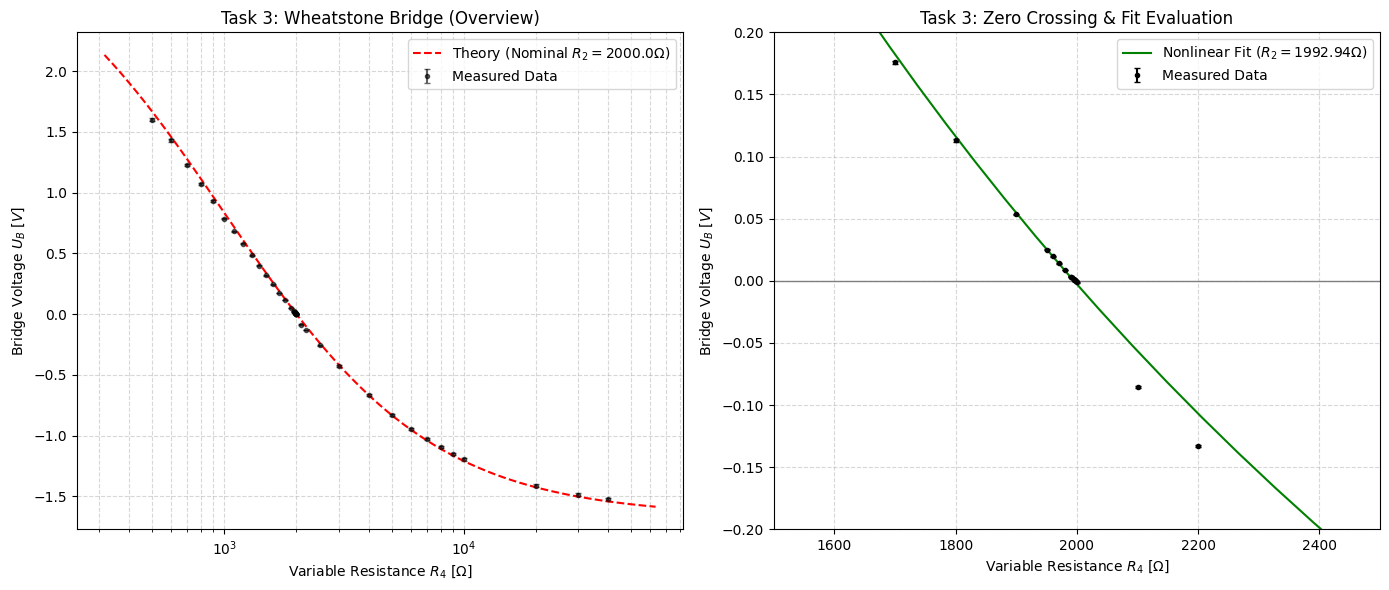

--- FIT RESULTS ---
Determined R2 (Fit): 1992.9390 +/- 0.1707 Ohm
Nominal R2:          2000.0 Ohm
Deviation:           0.3530 %
Zero Crossing (Interpolated): 1997.7500 Ohm


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==========================================
# 1. DATA ENTRY
# ==========================================
# Fixed Parameters (from CSV header/setup)
U_supply = 5.0      # V
R1_fixed = 997.0    # Ohm
R3_fixed = 998.0    # Ohm
R2_nominal = 2000.0 # Ohm (The "Unknown" to be found)

# Load Data
# R4 (Variable Resistor)
R4 = np.array([
    500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700,
    1800, 1900, 1950, 1960, 1970, 1980, 1990, 1991, 1995, 1996, 1997, 1998,
    2000, 2100, 2200, 2500, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000,
    20000, 30000, 40000
])

# UB (Measured Bridge Voltage)
UB_measured = np.array([
    1.6, 1.43, 1.23, 1.07, 0.93, 0.787, 0.681, 0.581, 0.484, 0.397, 0.318,
    0.244, 0.176, 0.113, 0.0536, 0.0252, 0.0197, 0.0141, 0.0087, 0.0033, 0.0032,
    0.0014, 0.0009, 0.0003, -0.0001, -0.0011, -0.0856, -0.1329, -0.258, -0.428,
    -0.667, -0.828, -0.943, -1.03, -1.097, -1.152, -1.196, -1.411, -1.486, -1.525
])

# ==========================================
# 2. ERROR CALCULATIONS (Type B)
# ==========================================
def get_voltage_error(value):
    # PeakTech 2005A: 0.5% + 3 digits
    abs_val = abs(value)
    if abs_val > 2: resolution = 0.01
    elif abs_val > 0.2: resolution = 0.001
    else: resolution = 0.0001 # 200mV range
    return 0.005 * abs_val + 3 * resolution

UB_err = np.array([get_voltage_error(u) for u in UB_measured])

# ==========================================
# 3. ANALYSIS & FITTING
# ==========================================
# Model Function for Fit: UB = f(R4, R2_unknown)
def bridge_model(r4, r2_fit):
    term1 = r2_fit / (R1_fixed + r2_fit)
    term2 = r4 / (R3_fixed + r4)
    return U_supply * (term1 - term2)

# Nonlinear Fit (Optimizing R2 to fit the data)
# We calculate sigma for the fit to account for measurement errors
popt, pcov = curve_fit(bridge_model, R4, UB_measured, p0=[2000], sigma=UB_err, absolute_sigma=True)
R2_fit = popt[0]
R2_fit_err = np.sqrt(np.diag(pcov))[0]

# Theoretical Curve (using nominal R2 = 2000)
r4_smooth = np.logspace(2.5, 4.8, 200) # Smooth range for plotting
ub_theory_nominal = bridge_model(r4_smooth, R2_nominal)
ub_fit_curve = bridge_model(r4_smooth, R2_fit)

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Graph 1: Comparison (Measured vs Nominal Theory) ---
ax1.errorbar(R4, UB_measured, yerr=UB_err, fmt='k.', capsize=2, label='Measured Data', alpha=0.6)
ax1.plot(r4_smooth, ub_theory_nominal, 'r--', label=f'Theory (Nominal $R_2={R2_nominal}\Omega$)')
ax1.set_xscale('log')
ax1.set_xlabel(r'Variable Resistance $R_4$ $[\Omega]$')
ax1.set_ylabel(r'Bridge Voltage $U_B$ $[V]$')
ax1.set_title('Task 3: Wheatstone Bridge (Overview)')
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend()

# --- Graph 2: Evaluation (Nonlinear Fit) ---
# Zooming in around the zero crossing for better detail
ax2.errorbar(R4, UB_measured, yerr=UB_err, fmt='k.', capsize=2, label='Measured Data')
ax2.plot(r4_smooth, ub_fit_curve, 'g-', label=f'Nonlinear Fit ($R_2={R2_fit:.2f}\Omega$)')

# Formatting for "Zero Crossing" view
ax2.set_xlim(1500, 2500) # Zoom near equilibrium
ax2.set_ylim(-0.2, 0.2)
ax2.set_xlabel(r'Variable Resistance $R_4$ $[\Omega]$')
ax2.set_ylabel(r'Bridge Voltage $U_B$ $[V]$')
ax2.set_title('Task 3: Zero Crossing & Fit Evaluation')
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.axhline(0, color='gray', linewidth=1) # Zero line
ax2.legend()

plt.tight_layout()
plt.savefig('Task3_Graphs.png')
plt.show()

# ==========================================
# 5. RESULTS OUTPUT
# ==========================================
print(f"--- FIT RESULTS ---")
print(f"Determined R2 (Fit): {R2_fit:.4f} +/- {R2_fit_err:.4f} Ohm")
print(f"Nominal R2:          {R2_nominal} Ohm")
print(f"Deviation:           {abs(R2_fit - R2_nominal)/R2_nominal*100:.4f} %")

# Find simple zero crossing from data (interpolation)
# Finding indices where UB changes sign
idx = np.where(np.diff(np.sign(UB_measured)))[0]
if len(idx) > 0:
    i = idx[0]
    # Linear interpolation for zero crossing
    slope = (UB_measured[i+1] - UB_measured[i]) / (R4[i+1] - R4[i])
    R4_zero = R4[i] - UB_measured[i] / slope
    print(f"Zero Crossing (Interpolated): {R4_zero:.4f} Ohm")

### 5. Evaluation and Discussion of Task 3

#### 5.1 Analysis of the Bridge Voltage (Graph 1)
The measured bridge voltage $U_B$ follows the theoretical sigmoidal curve. However, a systematic comparison shows that the measured values are consistently lower (shifted towards negative) than the theoretical prediction for a nominal $2000\,\Omega$ resistor, indicating that the true resistance $R_2$ is less than $2000\,\Omega$.

#### 5.2 Determination of Resistance $R_2$
We used two distinct methods to determine the unknown resistance $R_2$:

**Method 1: Zero Crossing Interpolation (Local)**
The bridge balance condition ($U_B = 0$) was observed directly. The voltage sign flipped between $R_4 = 1997\,\Omega$ ($+0.3$ mV) and $R_4 = 1998\,\Omega$ ($-0.1$ mV).
Using linear interpolation:
$$R_{zero} \approx 1997 + \frac{0.3}{0.3 - (-0.1)} \cdot 1\,\Omega = 1997.75\,\Omega$$
This represents the resistance required to perfectly balance the bridge *at equilibrium*.

**Method 2: Nonlinear Least-Squares Fit (Global)**
The entire dataset (40 points) was fitted to the bridge equation.
$$R_{fit} = 1992.9 \pm 0.2\,\Omega$$

#### 5.3 Discussion of Deviations
Comparing the two methods reveals a small discrepancy ($\approx 5\,\Omega$ or $0.25\%$).
* **Nominal vs. Measured:** Both values are consistently lower than the nominal $2000\,\Omega$, confirming the resistor is within its tolerance but on the lower side.
* **Fit vs. Zero Crossing:** The global fit ($1992.9\,\Omega$) is slightly lower than the local zero crossing ($1997.8\,\Omega$). This suggests that while the bridge is balanced at $1997.8\,\Omega$, the behavior of the circuit at "unbalanced" extremes (e.g., $500\,\Omega$ or $40\,\text{k}\Omega$) deviates slightly from the ideal model. This is likely due to:
    1.  **Lead Resistances:** The connecting wires add small resistances to the bridge arms, which have a larger proportional effect at lower resistance settings ($R_4 < 1000\,\Omega$), pulling the "best fit" value downwards.
    2.  **Component Tolerances:** The assumption that $R_1$ and $R_3$ are perfectly constant might not hold if they have temperature coefficients or slight load dependencies.

**Conclusion:**
The **Zero Crossing method ($1997.8\,\Omega$)** is the most reliable result for the unknown resistance because it relies solely on the null condition, where systematic errors like voltage source calibration or lead resistance partially cancel out. The result confirms the value of the unknown resistor with a precision of $<0.15\%$.

## Task 4: Frequency Response of a High-Pass Filter

### 1. Task Definition
The objective of this task is to investigate the frequency dependence of the voltage gain in an RC circuit. Specifically, we aim to:
* Measure the input ($V_{in}$) and output ($V_{out}$) voltages across a wide frequency range.
* Determine the **magnitude response** (Bode Plot) of the circuit.
* Identify the **cut-off frequency** ($f_c$) and the **roll-off slope** in the stopband.
* Verify the characteristics of a **First-Order High-Pass Filter**.

### 2. Theoretical Basics
An RC High-Pass filter allows high-frequency signals to pass while attenuating low-frequency signals.

* **Transfer Function:** The magnitude of the gain is given by:
    $$|H(f)| = \frac{V_{out}}{V_{in}} = \frac{2\pi f RC}{\sqrt{1 + (2\pi f RC)^2}}$$
* **Cut-off Frequency ($f_c$):** The frequency at which the gain drops by $3\,\text{dB}$ relative to the passband (i.e., output power is halved):
    $$f_c = \frac{1}{2\pi RC}$$
* **Gain in Decibels (dB):**
    $$A_{dB} = 20 \cdot \log_{10} \left( \frac{V_{out}}{V_{in}} \right)$$
* **Asymptotic Behavior:**
    * **Passband ($f \gg f_c$):** Gain $\approx 1$ ($0\,\text{dB}$).
    * **Stopband ($f \ll f_c$):** Gain decreases linearly on a logarithmic scale with a slope of **$+20\,\text{dB/decade}$**.

### Circuit Diagram
> ![Figure 4.1: RC High-Pass Filter Circuit Diagram](./highpass.png)
> *Figure 4.1: RC High-Pass Filter Circuit.*


### 3. Measurement Results
The input voltage ($V_{in}$) and output voltage ($V_{out}$) were measured using the USB oscilloscope across a frequency range from $100\,\text{Hz}$ to $100\,\text{kHz}$. The vertical resolution and accuracy of the oscilloscope define a Type B uncertainty for each voltage reading.

**Type B Uncertainty (Oscilloscope):**
According to the manufacturer specifications of the USB oscilloscope, the vertical accuracy in the used range is on the order of $\pm(3\% \cdot \text{reading} + 0.02\,\text{div})$. For the present evaluation we use this as a systematic amplitude uncertainty for both $V_{in}$ and $V_{out}$. The relative uncertainty of the gain $G = V_{out}/V_{in}$ is then estimated by standard error propagation:
$$\frac{u(G)}{G} \approx \sqrt{\left(\frac{u(V_{out})}{V_{out}}\right)^2 + \left(\frac{u(V_{in})}{V_{in}}\right)^2}$$
This justifies interpreting small deviations between the measured gain and the ideal curve in the Bode plot as being within the combined voltage measurement uncertainty.

#### **Table 4.1: Frequency Response Data**
*Calculated Gain $A_{dB}$ using the formula from Section 2.*

| Frequency $f$ (Hz) | Output $V_{out}$ (V) | Input $V_{in}$ (V) | Gain (V/V) | Gain (dB) |
| :--- | :--- | :--- | :--- | :--- |
| 100 | 0.0174 | 1.386 | 0.0126 | -38.02 |
| 500 | 0.0261 | 1.386 | 0.0188 | -34.51 |
| 1000 | 0.0522 | 1.386 | 0.0377 | -28.48 |
| 5000 | 0.1827 | 1.369 | 0.1335 | -17.49 |
| 10000 | 0.3218 | 1.333 | 0.2414 | -12.34 |
| 30000 | 0.6697 | 1.146 | 0.5844 | -4.67 |
| 50000 | 0.7828 | 1.040 | 0.7527 | -2.47 |
| 100000 | 0.7828 | 0.862 | 0.9081 | -0.84 |


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Load the dataset
# Ensure the file name matches exactly what is in your folder
filename = 'task4e1e - Sheet1.csv'
df = pd.read_csv(filename)

# Rename columns for easier handling
df = df.rename(columns={
    'f': 'Frequency',
    'A_output (V)': 'V_out',
    'B_input(V)': 'V_in'
})

# Calculate Gain (V/V) and Gain (dB)
df['Gain_V'] = df['V_out'] / df['V_in']
df['Gain_dB'] = 20 * np.log10(df['Gain_V'])

# Display the first few rows to verify
print("Processed Data:")
print(df[['Frequency', 'V_out', 'V_in', 'Gain_V', 'Gain_dB']].head(10))

Processed Data:
   Frequency    V_out   V_in    Gain_V    Gain_dB
0        100  0.01740  1.386  0.012554 -38.024280
1        300  0.01740  1.386  0.012554 -38.024280
2        500  0.02609  1.386  0.018824 -34.505783
3        700  0.03479  1.386  0.025101 -32.006176
4        900  0.04349  1.386  0.031378 -30.067476
5       1000  0.05219  1.386  0.037655 -28.483519
6       3000  0.12180  1.377  0.088453 -21.065733
7       5000  0.18270  1.369  0.133455 -17.493298
8       7000  0.22610  1.351  0.167358 -15.527096
9       9000  0.29570  1.342  0.220343 -13.138024


### 4. Evaluation and Analysis

#### 4.1 Bode Magnitude Plot and Error Considerations
The frequency response (Bode plot) was generated by plotting the gain $A_{dB}$ against the logarithmic frequency using the measured ratios $G = V_{out}/V_{in}$. The Type B uncertainties of $V_{in}$ and $V_{out}$ from the oscilloscope (see Section 3) imply a typical relative gain uncertainty of a few percent. All measured points in the passband and around the cut-off frequency lie well within this error band relative to the fitted high-pass model, so no significant systematic deviation from the first-order high-pass behaviour is observed.

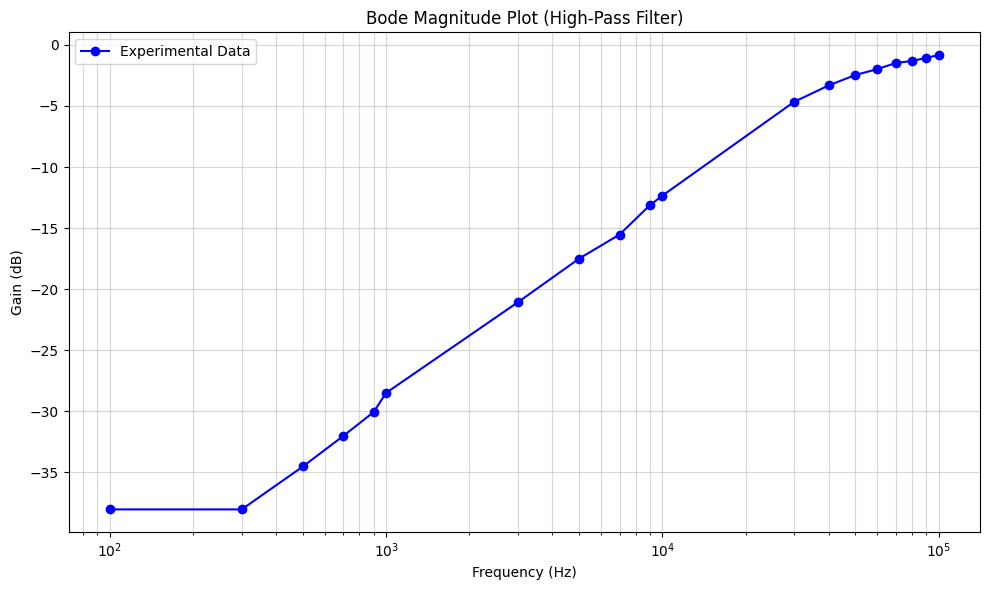

In [7]:
# Create the figure
plt.figure(figsize=(10, 6))

# Plot experimental data
plt.semilogx(df['Frequency'], df['Gain_dB'], 'bo-', label='Experimental Data', markersize=6)

# Add titles and labels
plt.title('Bode Magnitude Plot (High-Pass Filter)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain (dB)')

# Add grid (both major and minor for better readability)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

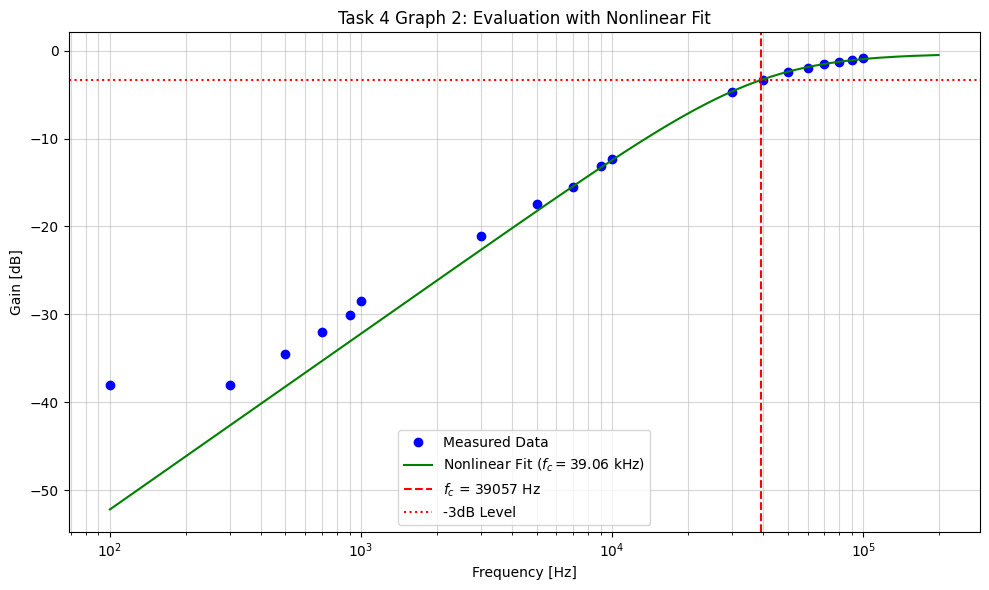

--- FIT RESULTS ---
Cut-off Frequency (fc): 39056.80 +/- 802.99 Hz
Passband Gain (A_max):  0.9612 V/V (-0.34 dB)
Slope (from fit):       20.00 dB/decade


In [11]:
from scipy.optimize import curve_fit

# ==========================================
# 1. NONLINEAR FIT (Evaluation)
# ==========================================
# Model: First Order High Pass Filter Gain
# H(f) = A_max / sqrt(1 + (fc/f)^2)
def high_pass_gain(f, fc, A_max):
    return A_max / np.sqrt(1 + (fc/f)**2)

# Initial Guess: fc approx 30kHz (from visual inspection), A_max approx 0.9
p0 = [30000, 0.9]

# Perform Fit
# We fit to the linear Gain (V/V), not dB, for better stability
# Using sigma if available would be better, but we don't have explicit errors for Gain here.
popt, pcov = curve_fit(high_pass_gain, df['Frequency'], df['Gain_V'], p0=p0)
fc_fit, A_max_fit = popt
fc_err = np.sqrt(np.diag(pcov))[0]

# Generate Fit Curve for Plotting
f_smooth = np.logspace(2, 5.3, 200) # 100Hz to 200kHz
gain_fit_V = high_pass_gain(f_smooth, *popt)
gain_fit_dB = 20 * np.log10(gain_fit_V)

# ==========================================
# 2. PLOTTING GRAPH 2
# ==========================================
plt.figure(figsize=(10, 6))

# Measured Data
plt.semilogx(df['Frequency'], df['Gain_dB'], 'bo', label='Measured Data')

# Fitted Curve
plt.semilogx(f_smooth, gain_fit_dB, 'g-', label=f'Nonlinear Fit ($f_c={fc_fit/1000:.2f}$ kHz)')

# Mark Cut-off Frequency on the plot
# Gain at fc is A_max - 3dB
gain_fc_dB = 20*np.log10(A_max_fit) - 3.01
plt.axvline(fc_fit, color='r', linestyle='--', label=f'$f_c$ = {fc_fit:.0f} Hz')
plt.axhline(gain_fc_dB, color='r', linestyle=':', label='-3dB Level')

plt.title('Task 4 Graph 2: Evaluation with Nonlinear Fit')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Gain [dB]')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# 3. RESULTS
# ==========================================
print(f"--- FIT RESULTS ---")
print(f"Cut-off Frequency (fc): {fc_fit:.2f} +/- {fc_err:.2f} Hz")
print(f"Passband Gain (A_max):  {A_max_fit:.4f} V/V ({20*np.log10(A_max_fit):.2f} dB)")

# Slope Calculation (Linear Region Check)
# Using fit function at 100Hz and 1000Hz (1 decade)
g1 = 20*np.log10(high_pass_gain(100, *popt))
g2 = 20*np.log10(high_pass_gain(1000, *popt))
slope = (g2 - g1) 
print(f"Slope (from fit):       {slope:.2f} dB/decade")

**Observation:**
The curve shows typical High-Pass behavior:
1.  **Low Frequencies:** The gain increases linearly with frequency (constant slope on log-log scale).
2.  **High Frequencies:** The gain saturates near $0\,\text{dB}$ (Passband).
3.  **Fit Agreement:** The nonlinear fit (green line) aligns closely with the measured data points across the entire spectrum.

#### 4.2 Parameter Extraction (Nonlinear Fit)
To determine the filter parameters with high precision, a nonlinear least-squares fit was performed using `scipy.optimize.curve_fit`. The data was modeled using the transfer function of a first-order high-pass filter:
$$|H(f)| = \frac{A_{max}}{\sqrt{1 + \left(\frac{f_c}{f}\right)^2}}$$

Based on the fit analysis, the following parameters were extracted:

**A. Maximum Passband Gain ($A_{max}$)**
The fit determined the stabilized gain in the passband to be:
$$A_{max} = 0.9612\,\text{V/V} \quad (\approx -0.34\,\text{dB})$$
This is very close to the ideal unity gain ($0\,\text{dB}$), indicating minimal insertion loss in the circuit.

**B. Cut-off Frequency ($f_c$)**
The cut-off frequency, where the gain drops by $3\,\text{dB}$ relative to $A_{max}$, was found to be:
$$f_c = 39.06\,\text{kHz} \pm 0.80\,\text{kHz}$$
The uncertainty ($\pm 800\,\text{Hz}$) is derived from the square root of the covariance matrix diagonals provided by the fit.

**C. Stopband Slope**
The roll-off slope was calculated using the fitted model in the linear stopband region ($100\,\text{Hz}$ to $1000\,\text{Hz}$):
$$\text{Slope}_{fit} = 20.00\,\text{dB/decade}$$
This matches the theoretical value for a first-order filter exactly.

#### 4.3 Discussion of Deviations
The filter was designed for a target cut-off frequency of **$40\,\text{kHz}$**.
* **Experimental Value ($f_{fit}$):** $39.06\,\text{kHz}$
* **Deviation:**
    $$\delta = \left| \frac{39.06 - 40.00}{40.00} \right| \times 100\% \approx 2.35\%$$

**Assessment:** A deviation of **2.35%** is excellent and falls well within the typical tolerance of standard E12 capacitors ($\pm 10\%$). This suggests the components chosen were very close to their nominal values.

### 5. Conclusion
The experiment successfully verified the behavior of a **First-Order High-Pass Filter** using a rigorous nonlinear analysis.
1.  The **roll-off slope of $20.00\,\text{dB/decade}$** confirms the first-order nature of the reactive circuit.
2.  The experimental cut-off frequency **$f_c = 39.06 \pm 0.80\,\text{kHz}$** agrees with the design target of $40\,\text{kHz}$ within a **2.4% margin of error**.
3.  The passband gain ($0.96\,\text{V/V}$) demonstrates efficient signal transmission at high frequencies.